# Centrality

- Hepatocyte

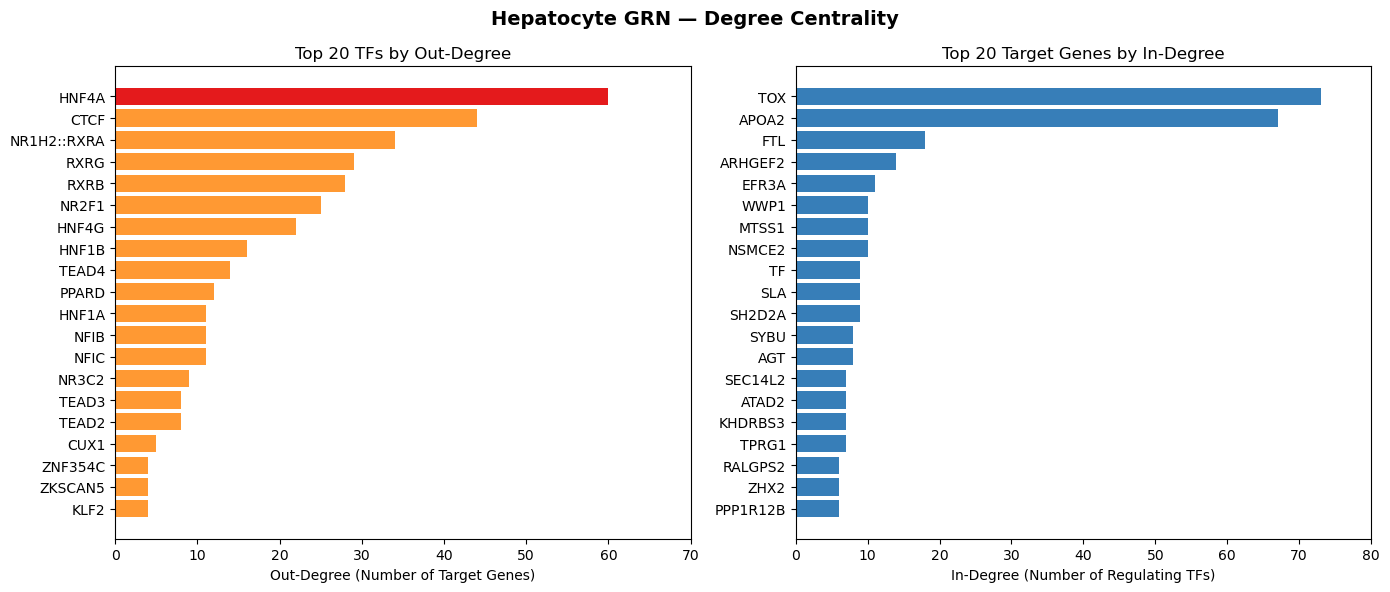

In [30]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/All_GRN_Weights_Hepatocytes.csv')

# 2. 필터링 (weight > 0.1)
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].mean().to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].mean().to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화 (공통 스케일)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 70)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 80)

plt.suptitle('Hepatocyte GRN — Degree Centrality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Mesenchymal

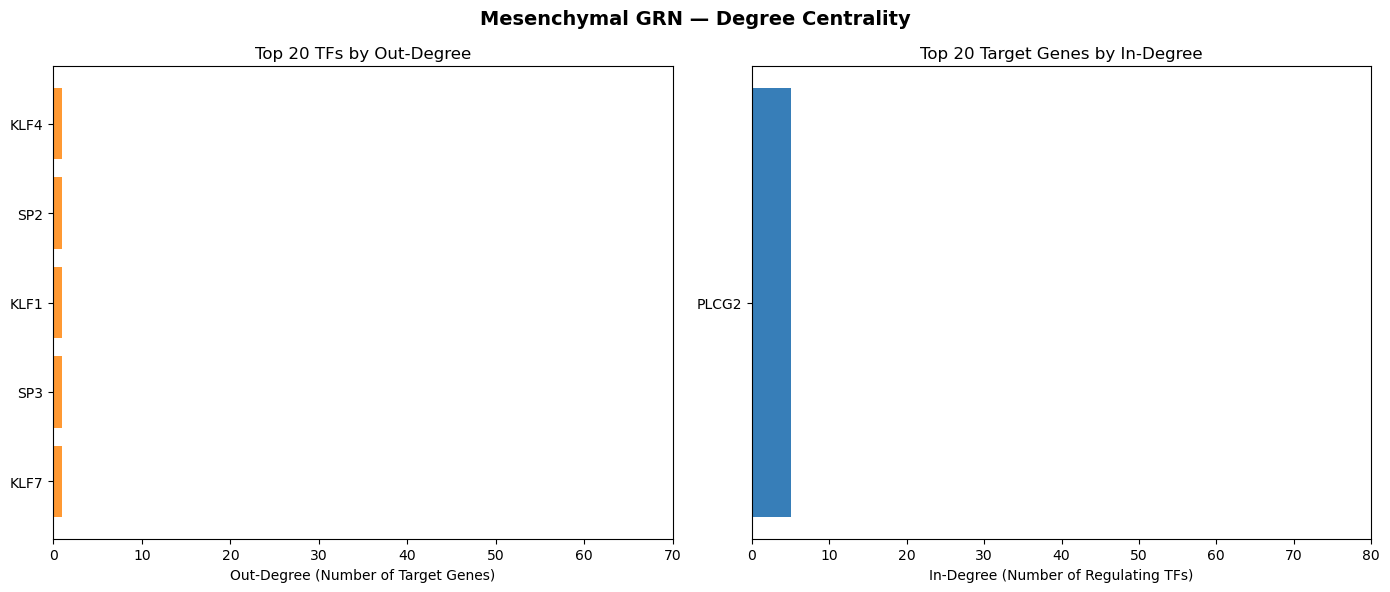

In [31]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Mesenchymal_All_GRN_Weights.csv')

# 2. 필터링 (weight > 0.1)
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].mean().to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].mean().to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화 (공통 스케일)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 70)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 80)

plt.suptitle('Mesenchymal GRN — Degree Centrality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Mesenchymal_All_GRN_Weights.csv')
filtered = df[df['grn_weight'] > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"Mesenchymal — All TF-Gene edges (ρ > 0.1): {len(result)}")
result

Mesenchymal — All TF-Gene edges (ρ > 0.1): 5


,tf_name,gene,grn_weight,|ρ|
1,KLF4,PLCG2,0.108968,0.108968
2,SP2,PLCG2,0.108404,0.108404
3,KLF1,PLCG2,0.107180,0.107180
4,SP3,PLCG2,0.106673,0.106673
5,KLF7,PLCG2,0.100017,0.100017


- Macrophage

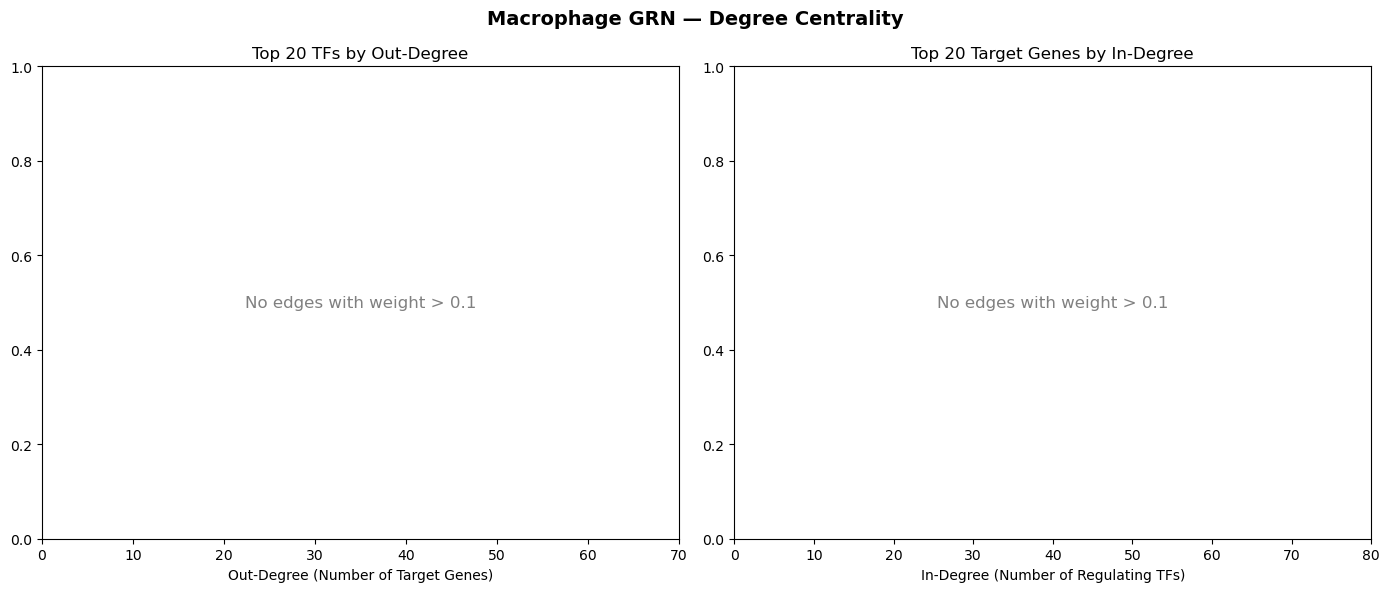

In [33]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Macrophages_All_GRN_Weights.csv')

# 2. 필터링 (weight > 0.1)
filtered_df = df[df['grn_weight'] > 0.1].copy()

if len(filtered_df) == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 70)
    axes[0].text(35, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=12, color='grey')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 80)
    axes[1].text(40, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=12, color='grey')
    plt.suptitle('Macrophage GRN — Degree Centrality', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # 3. 네트워크 그래프 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

    # 4. Degree Centrality 계산
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].mean().to_dict()
    gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].mean().to_dict()

    nodes = list(G.nodes())
    tfs = set(filtered_df['tf_name'])

    centrality_df = pd.DataFrame({
        'node': nodes,
        'in_degree': [in_degree.get(n, 0) for n in nodes],
        'out_degree': [out_degree.get(n, 0) for n in nodes],
        'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
        'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
    }).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

    # 5. Degree Centrality 시각화 (공통 스케일)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # (A) TF Out-Degree
    tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
    top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
    second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
    is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
    colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
    axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 70)

    # (B) Target Gene In-Degree
    gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
    axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 80)

    plt.suptitle('Macrophage GRN — Degree Centrality', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [34]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Macrophages_All_GRN_Weights.csv')
filtered = df[df['grn_weight'] > 0.1].copy()
if len(filtered) == 0:
    print("Macrophage — No TF-Gene edges with ρ > 0.1")
else:
    filtered['|ρ|'] = filtered['grn_weight'].abs()
    result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
    result.index = result.index + 1
    print(f"Macrophage — All TF-Gene edges (ρ > 0.1): {len(result)}")
    display(result)

Macrophage — No TF-Gene edges with ρ > 0.1


- T cell

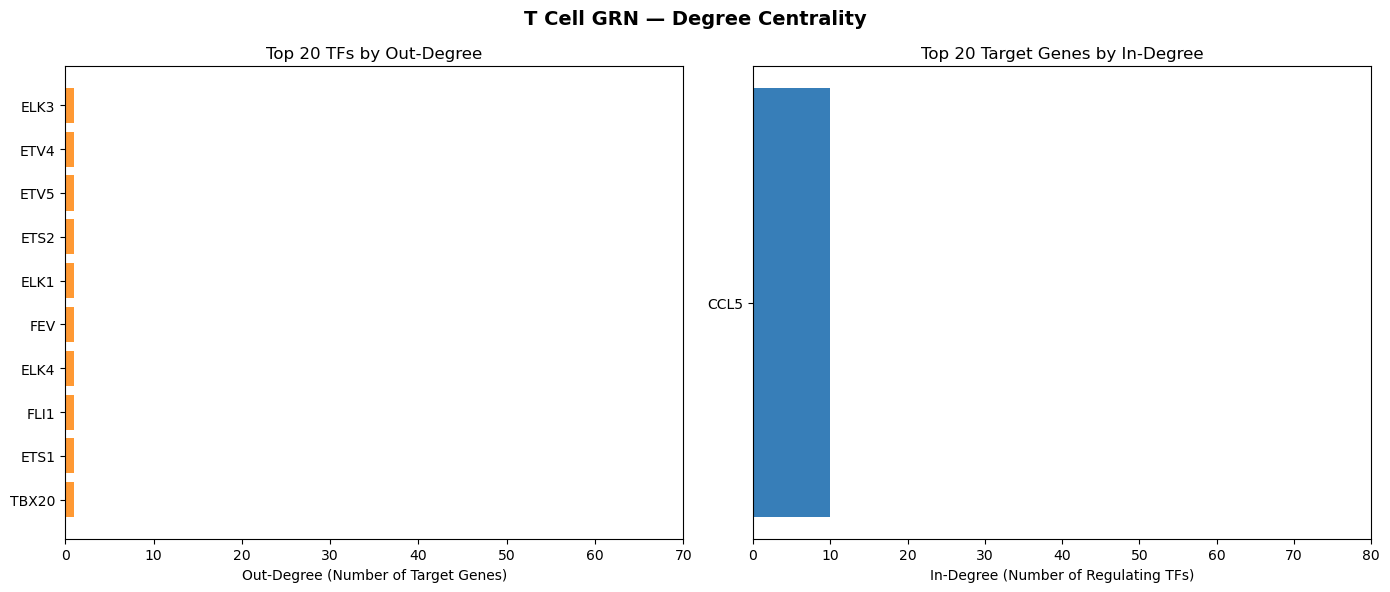

In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/T_Cells_All_GRN_Weights.csv')

# 2. 필터링 (weight > 0.1)
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].mean().to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].mean().to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화 (공통 스케일)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 70)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 80)

plt.suptitle('T Cell GRN — Degree Centrality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/T_Cells_All_GRN_Weights.csv')
filtered = df[df['grn_weight'] > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"T Cell — All TF-Gene edges (ρ > 0.1): {len(result)}")
result

T Cell — All TF-Gene edges (ρ > 0.1): 10


,tf_name,gene,grn_weight,|ρ|
1,ELK3,CCL5,0.150047,0.150047
2,ETV4,CCL5,0.131890,0.131890
3,ETV5,CCL5,0.131767,0.131767
4,ETS2,CCL5,0.129792,0.129792
5,ELK1,CCL5,0.126735,0.126735
6,FEV,CCL5,0.119976,0.119976
7,ELK4,CCL5,0.119100,0.119100
8,FLI1,CCL5,0.112674,0.112674
9,ETS1,CCL5,0.109994,0.109994
10,TBX20,CCL5,0.109919,0.109919


- NK Cell

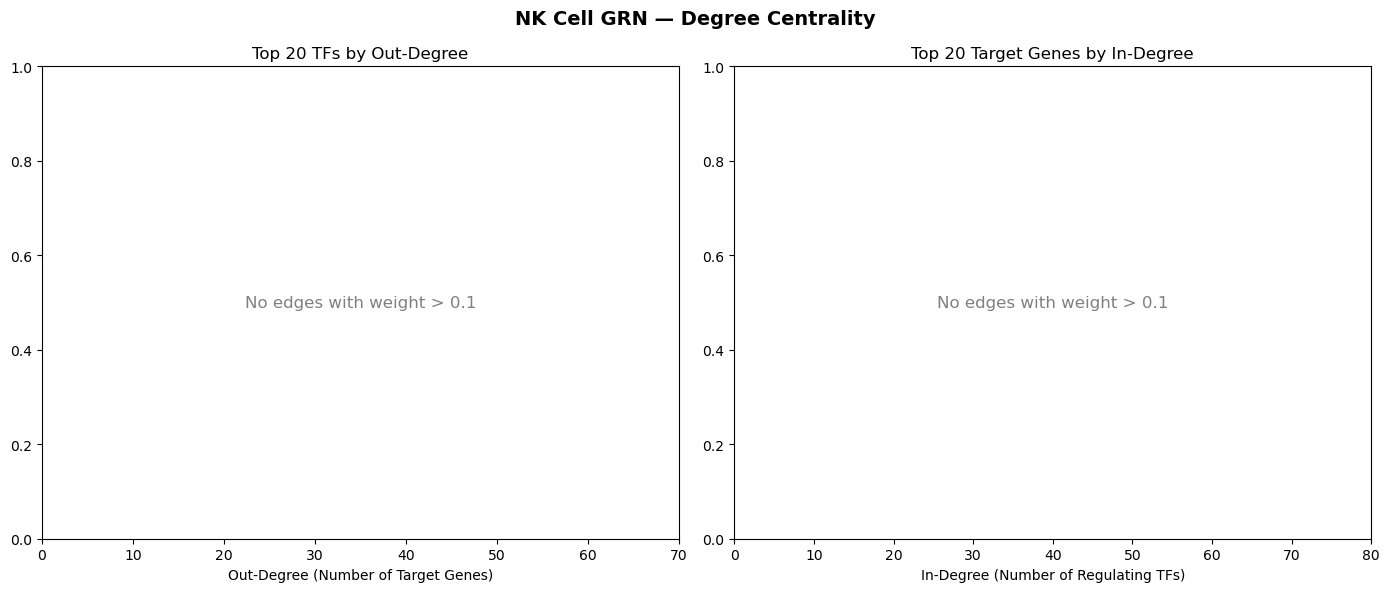

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/NK_Cells_All_GRN_Weights.csv')

# 2. 필터링 (weight > 0.1)
filtered_df = df[df['grn_weight'] > 0.1].copy()

if len(filtered_df) == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 70)
    axes[0].text(35, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=12, color='grey')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 80)
    axes[1].text(40, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=12, color='grey')
    plt.suptitle('NK Cell GRN — Degree Centrality', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # 3. 네트워크 그래프 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

    # 4. Degree Centrality 계산
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].mean().to_dict()
    gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].mean().to_dict()

    nodes = list(G.nodes())
    tfs = set(filtered_df['tf_name'])

    centrality_df = pd.DataFrame({
        'node': nodes,
        'in_degree': [in_degree.get(n, 0) for n in nodes],
        'out_degree': [out_degree.get(n, 0) for n in nodes],
        'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
        'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
    }).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

    # 5. Degree Centrality 시각화 (공통 스케일)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # (A) TF Out-Degree
    tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
    top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
    second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
    is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
    colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
    axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 70)

    # (B) Target Gene In-Degree
    gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
    axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 80)

    plt.suptitle('NK Cell GRN — Degree Centrality', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [2]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/NK_Cells_All_GRN_Weights.csv')
filtered = df[df['grn_weight'] > 0.1].copy()
if len(filtered) == 0:
    print("NK Cell — No TF-Gene edges with ρ > 0.1")
else:
    filtered['|ρ|'] = filtered['grn_weight'].abs()
    result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
    result.index = result.index + 1
    print(f"NK Cell — All TF-Gene edges (ρ > 0.1): {len(result)}")
    display(result)

NK Cell — No TF-Gene edges with ρ > 0.1
